# 🌳 Day 25 — Decision Tree Classification

## Student Performance Prediction

### Objective
Build a Machine Learning model to predict whether a student will **Pass (1) or Fail (0)** using study hours and previous scores.

### Algorithm
- Decision Tree Classification
- Gini Impurity
- Entropy
- Information Gain
- Model Evaluation
- Decision Tree Visualization
- Overfitting Control

### Tools
Python | Pandas | Matplotlib | Scikit-learn


## 🎯 Learning Objectives

By the end of this practical, I will learn how to:

1. Create a classification dataset.
2. Explore and understand the data.
3. Separate features and target labels.
4. Split data into training and testing sets.
5. Train a Decision Tree Classifier.
6. Make predictions.
7. Evaluate model performance.
8. Understand the confusion matrix.
9. Visualize the decision tree.
10. Make predictions for new students.
11. Understand Gini vs Entropy.
12. Control overfitting using `max_depth`.


In [1]:
# Import Pandas for creating and handling tabular data
import pandas as pd

# Import Matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import DecisionTreeClassifier to build the classification model
from sklearn.tree import DecisionTreeClassifier

# Import plot_tree to visualize the trained decision tree
from sklearn.tree import plot_tree

# Import metrics to evaluate the model's performance
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Display a message to confirm that the libraries are imported
print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# Create a dictionary containing student performance data
data = {
    # Number of hours each student studies
    "Study_Hours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 8,
        9, 9, 10, 10, 11
    ],

    # Previous examination scores of the students
    "Previous_Score": [
        35, 40, 45, 42, 48,
        50, 55, 58, 60, 62,
        65, 68, 70, 72, 75,
        78, 82, 85, 90, 94
    ],

    # Target labels: 0 means Fail and 1 means Pass
    "Result": [
        0, 0, 0, 0, 0,
        0, 0, 0, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

# Display a confirmation message after creating the dataset
print("Dataset created successfully!")


Dataset created successfully!


In [3]:
# Convert the dictionary into a Pandas DataFrame
df = pd.DataFrame(data)

# Display the first five rows of the dataset
df.head()


,Study_Hours,Previous_Score,Result
0,1,35,0
1,2,40,0
2,2,45,0
3,3,42,0
4,3,48,0


In [4]:
# Display the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display all column names
print("Column names:", df.columns.tolist())

# Display the data types and non-null counts of each column
df.info()


Dataset shape: (20, 3)
Column names: ['Study_Hours', 'Previous_Score', 'Result']
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     20 non-null     int64
 1   Previous_Score  20 non-null     int64
 2   Result          20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [5]:
# Display descriptive statistics for the numerical columns
df.describe()


,Study_Hours,Previous_Score,Result
count,20.000000,20.000000,20.000000
mean,6.000000,63.700000,0.600000
std,2.991215,17.204956,0.502625
min,1.000000,35.000000,0.000000
25%,3.750000,49.500000,0.000000
50%,6.000000,63.500000,1.000000
75%,8.250000,75.750000,1.000000
max,11.000000,94.000000,1.000000


In [6]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Display the missing-value count
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
Study_Hours       0
Previous_Score    0
Result            0
dtype: int64


In [7]:
# Count how many students belong to each target class
result_counts = df["Result"].value_counts().sort_index()

# Display the class counts
print("Target distribution:")
print(result_counts)

# Display the meaning of each target label
print("\n0 = Fail")
print("1 = Pass")


Target distribution:
Result
0     8
1    12
Name: count, dtype: int64

0 = Fail
1 = Pass


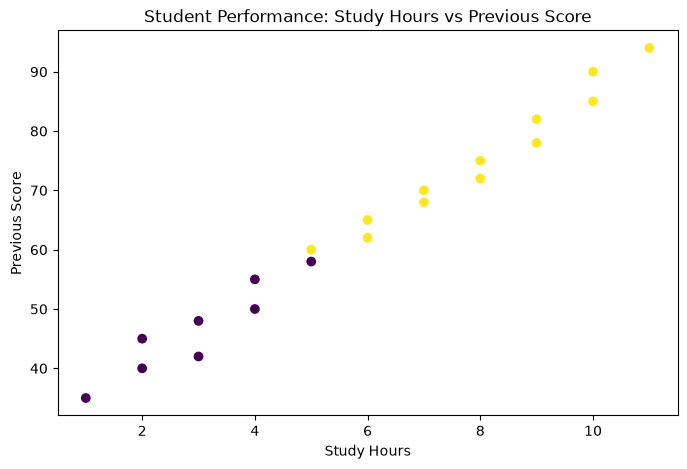

In [8]:
# Create a figure for the scatter plot
plt.figure(figsize=(8, 5))

# Plot study hours against previous scores
# Use Result to distinguish the Pass and Fail classes
plt.scatter(
    df["Study_Hours"],
    df["Previous_Score"],
    c=df["Result"]
)

# Add a label to the horizontal axis
plt.xlabel("Study Hours")

# Add a label to the vertical axis
plt.ylabel("Previous Score")

# Add a title to the chart
plt.title("Student Performance: Study Hours vs Previous Score")

# Display the chart
plt.show()


## 🔹 Features and Target

### Features (`X`)
The model uses these input features:
- `Study_Hours`
- `Previous_Score`

### Target (`y`)
The model predicts:
- `0` → Fail
- `1` → Pass


In [9]:
# X contains the input features used to make predictions
X = df.drop(columns=["Result"])

# y contains the target labels that the model must predict
y = df["Result"]

# Display the shapes of X and y
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display the first five rows of the features
print("\nInput features:")
print(X.head())

# Display the first five target labels
print("\nTarget labels:")
print(y.head())


Features shape: (20, 2)
Target shape: (20,)

Input features:
   Study_Hours  Previous_Score
0            1              35
1            2              40
2            2              45
3            3              42
4            3              48

Target labels:
0    0
1    0
2    0
3    0
4    0
Name: Result, dtype: int64


## 🔹 Train/Test Split

We divide the dataset into:

- **80% Training Data** → used to learn patterns.
- **20% Testing Data** → used to evaluate the model on unseen data.

`random_state=42` makes the split reproducible.

`stratify=y` helps preserve the class distribution in both sets.


In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the number of samples used for training
print("Training samples:", len(X_train))

# Display the number of samples used for testing
print("Testing samples:", len(X_test))


Training samples: 16
Testing samples: 4


In [11]:
# Display the first five rows of the training features
print("Training Features:")
print(X_train.head())

# Display the first five training target labels
print("\nTraining Target:")
print(y_train.head())


Training Features:
    Study_Hours  Previous_Score
8             5              60
0             1              35
16            9              82
18           10              90
13            8              72

Training Target:
8     1
0     0
16    1
18    1
13    1
Name: Result, dtype: int64


In [12]:
# Display the first five rows of the testing features
print("Testing Features:")
print(X_test.head())

# Display the testing target labels
print("\nTesting Target:")
print(y_test.head())


Testing Features:
    Study_Hours  Previous_Score
6             4              55
3             3              42
14            8              75
17           10              85

Testing Target:
6     0
3     0
14    1
17    1
Name: Result, dtype: int64


In [13]:
# Display the shape of the training features
print("X_train shape:", X_train.shape)

# Display the shape of the testing features
print("X_test shape:", X_test.shape)

# Display the shape of the training target
print("y_train shape:", y_train.shape)

# Display the shape of the testing target
print("y_test shape:", y_test.shape)


X_train shape: (16, 2)
X_test shape: (4, 2)
y_train shape: (16,)
y_test shape: (4,)


## 🌳 Create the Decision Tree

Decision Trees split data using feature-based rules.

For classification, we can use criteria such as:

- Gini Impurity
- Entropy

Here we start with the default-style `gini` criterion.


In [14]:
# Create a Decision Tree Classifier
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Display the model configuration
print(model)


DecisionTreeClassifier(random_state=42)


In [15]:
# Train the Decision Tree using the training features and target labels
model.fit(X_train, y_train)

# Display a confirmation message
print("Decision Tree model trained successfully!")


Decision Tree model trained successfully!


In [16]:
# Get the maximum depth of the trained decision tree
tree_depth = model.get_depth()

# Display the tree depth
print("Tree Depth:", tree_depth)


Tree Depth: 1


In [17]:
# Get the number of leaf nodes in the trained tree
number_of_leaves = model.get_n_leaves()

# Display the number of leaves
print("Number of Leaves:", number_of_leaves)


Number of Leaves: 2


## 🔮 Make Predictions

The trained model can now use `X_test` to predict whether each test student will pass or fail.


In [18]:
# Use the trained model to predict the results of the test data
y_pred = model.predict(X_test)

# Display the predicted labels
print("Predictions:")
print(y_pred)


Predictions:
[0 0 1 1]


In [19]:
# Create a DataFrame to compare actual and predicted results
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Display the comparison table
comparison


,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,1


## 📊 Model Evaluation

We will evaluate the model using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score

Because this is a very small educational dataset, these metrics should not be treated as real-world performance estimates.


In [20]:
# Calculate the accuracy of the Decision Tree
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy as a decimal value
print("Accuracy:", accuracy)

# Convert accuracy into percentage
print("Accuracy (%):", accuracy * 100)


Accuracy: 1.0
Accuracy (%): 100.0


In [21]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[2 0]
 [0 2]]


### Confusion Matrix

```text
                 Predicted
                 Fail   Pass

Actual  Fail      TN     FP
        Pass      FN     TP
```

- **TN** → Correctly predicted Fail
- **FP** → Fail predicted as Pass
- **FN** → Pass predicted as Fail
- **TP** → Correctly predicted Pass


In [22]:
# Generate precision, recall and F1-score for each class
report = classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"]
)

# Display the classification report
print(report)


              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## 🌳 Visualize the Decision Tree

The visualization lets us see:

- Feature used for a split
- Split threshold
- Gini impurity
- Number of samples
- Class distribution
- Final predicted class


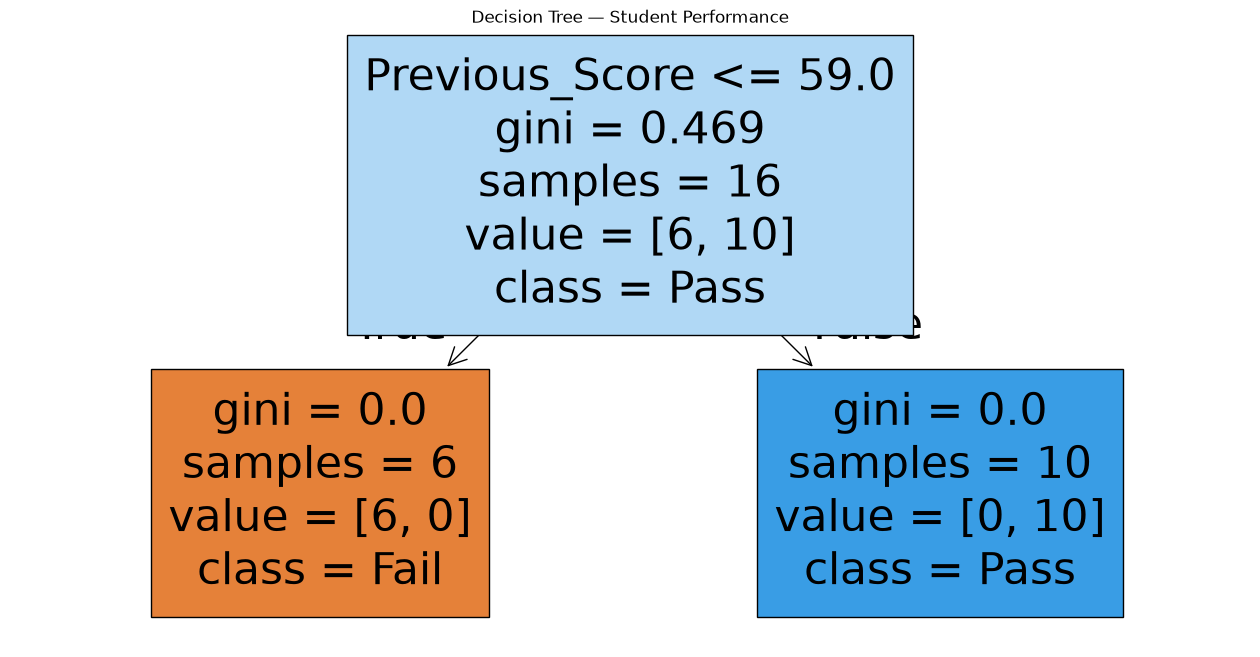

In [23]:
# Create a large figure so the complete tree is easier to read
plt.figure(figsize=(16, 8))

# Draw the trained Decision Tree
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)

# Add a title to the visualization
plt.title("Decision Tree — Student Performance")

# Display the tree
plt.show()


## 🔎 Understanding a Tree Node

A node may display information similar to:

```text
Study_Hours <= threshold
gini = ...
samples = ...
value = [...]
class = ...
```

### Meaning

- **Feature <= threshold** → rule used to split the data.
- **gini** → impurity of the node.
- **samples** → number of training samples reaching the node.
- **value** → number of samples in each class.
- **class** → predicted class at that node.


## 🎓 New Student Prediction

Now we will give the trained model a new student and ask it to predict the result.


In [24]:
# Create a new student with study hours and previous score
new_student = pd.DataFrame({
    "Study_Hours": [6.5],
    "Previous_Score": [67]
})

# Display the new student's input features
new_student


,Study_Hours,Previous_Score
0,6.5,67


In [25]:
# Predict the result of the new student
prediction = model.predict(new_student)

# Display the predicted class
print("Prediction:", prediction)


Prediction: [1]


In [26]:
# Check the predicted class and display a readable result
if prediction[0] == 1:
    print("Student Result: PASS")
else:
    print("Student Result: FAIL")


Student Result: PASS


In [27]:
# Calculate the class probabilities for the new student
probability = model.predict_proba(new_student)

# Display the probability for each class
print("Probability:")
print(probability)

# Display the class order used by the model
print("Class order:", model.classes_)


Probability:
[[0. 1.]]
Class order: [0 1]


## 🧠 Gini Impurity

Gini Impurity measures how mixed the classes are in a node.

### Formula

`Gini = 1 - Σ(pᵢ²)`

For a pure node, Gini is `0`.

For a binary classification problem, the maximum Gini impurity is `0.5` when the classes are equally mixed.

The Decision Tree generally chooses splits that reduce impurity.


In [28]:
# Define a function to calculate Gini Impurity manually
def gini_impurity(y):
    # Count how many times each class appears
    class_counts = {}

    # Loop through every target value
    for value in y:
        # Increase the count for the current class
        class_counts[value] = class_counts.get(value, 0) + 1

    # Calculate the total number of samples
    total = len(y)

    # Start the sum of squared probabilities at zero
    probability_squared_sum = 0

    # Calculate the squared probability of each class
    for count in class_counts.values():
        # Calculate the probability of the class
        probability = count / total

        # Add the squared probability to the running total
        probability_squared_sum += probability ** 2

    # Calculate and return Gini Impurity
    return 1 - probability_squared_sum


In [29]:
# Create a pure node containing only Pass samples
pure_node = [1, 1, 1, 1, 1]

# Create a mixed node containing both Pass and Fail samples
mixed_node = [0, 0, 1, 1, 1]

# Calculate Gini Impurity for the pure node
pure_gini = gini_impurity(pure_node)

# Calculate Gini Impurity for the mixed node
mixed_gini = gini_impurity(mixed_node)

# Display both Gini values
print("Pure node Gini:", pure_gini)
print("Mixed node Gini:", mixed_gini)


Pure node Gini: 0.0
Mixed node Gini: 0.48


## 🧠 Entropy

Entropy measures the uncertainty or impurity in a node.

### Formula

`Entropy = -Σ pᵢ log₂(pᵢ)`

For a pure node:

`Entropy = 0`

For a binary 50/50 node:

`Entropy = 1`

Information Gain is based on the reduction in entropy after a split.


In [30]:
# Import the math module for logarithm calculations
import math

# Define a function to calculate entropy
def entropy(y):
    # Count how many times each class appears
    class_counts = {}

    # Loop through every target value
    for value in y:
        # Increase the count for the current class
        class_counts[value] = class_counts.get(value, 0) + 1

    # Calculate the total number of samples
    total = len(y)

    # Start the entropy value at zero
    result = 0

    # Calculate the contribution of each class
    for count in class_counts.values():
        # Calculate the class probability
        probability = count / total

        # Add the entropy contribution
        result -= probability * math.log2(probability)

    # Return the final entropy
    return result


In [31]:
# Calculate entropy for a pure node
pure_entropy = entropy([1, 1, 1, 1, 1])

# Calculate entropy for a perfectly mixed binary node
mixed_entropy = entropy([0, 0, 1, 1])

# Display the entropy values
print("Pure node Entropy:", pure_entropy)
print("Mixed node Entropy:", mixed_entropy)


Pure node Entropy: 0.0
Mixed node Entropy: 1.0


## 📈 Information Gain

Information Gain measures how much uncertainty is reduced by a split.

### Formula

`Information Gain = Parent Entropy - Weighted Child Entropy`

A split with higher Information Gain reduces more uncertainty.

Standard terminology associates Information Gain with entropy-based splitting.


In [32]:
# Define a function to calculate Information Gain
def information_gain(parent, left, right):
    # Calculate the entropy of the parent node
    parent_entropy = entropy(parent)

    # Calculate the weight of the left child
    left_weight = len(left) / len(parent)

    # Calculate the weight of the right child
    right_weight = len(right) / len(parent)

    # Calculate the weighted entropy of both child nodes
    weighted_child_entropy = (
        left_weight * entropy(left)
        + right_weight * entropy(right)
    )

    # Calculate and return Information Gain
    return parent_entropy - weighted_child_entropy


In [33]:
# Create a parent node with mixed Pass and Fail classes
parent = [0, 0, 0, 1, 1, 1]

# Create two pure child nodes
left = [0, 0, 0]
right = [1, 1, 1]

# Calculate Information Gain for the split
gain = information_gain(parent, left, right)

# Display the Information Gain
print("Information Gain:", gain)


Information Gain: 1.0


## ⚖️ Gini vs Entropy

Both criteria are used to evaluate classification splits.

| Criterion | Formula | Meaning |
|---|---|---|
| Gini | `1 - Σp²` | Impurity |
| Entropy | `-Σp log₂p` | Uncertainty |

### Important

- Both generally prefer purer child nodes.
- Gini is the default criterion in `DecisionTreeClassifier`.
- Entropy is information-theoretic.
- Raw Gini and Entropy values should not be compared directly because they use different scales.


In [34]:
# Create a Decision Tree using Entropy as the splitting criterion
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

# Train the Entropy-based Decision Tree
entropy_model.fit(X_train, y_train)

# Predict the test data using the Entropy-based model
entropy_pred = entropy_model.predict(X_test)

# Calculate the accuracy of the Entropy-based model
entropy_accuracy = accuracy_score(
    y_test,
    entropy_pred
)

# Display the Entropy model accuracy
print("Entropy Tree Accuracy:", entropy_accuracy)


Entropy Tree Accuracy: 1.0


In [35]:
# Calculate the accuracy of the Gini-based Decision Tree
gini_accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy of both criteria
print("Gini Accuracy:", gini_accuracy)
print("Entropy Accuracy:", entropy_accuracy)


Gini Accuracy: 1.0
Entropy Accuracy: 1.0


## ⚠️ Overfitting in Decision Trees

A Decision Tree can grow very deep and memorize training data.

### Common controls

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_leaf_nodes`

A simpler tree can generalize better, but the appropriate settings should be selected using validation or cross-validation rather than one tiny test set.


In [36]:
# Create a simpler Decision Tree with a maximum depth of 3
simple_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

# Train the simpler Decision Tree
simple_model.fit(X_train, y_train)

# Predict the test data using the simpler model
simple_pred = simple_model.predict(X_test)

# Calculate the accuracy of the simpler model
simple_accuracy = accuracy_score(
    y_test,
    simple_pred
)

# Display the depth and accuracy of the simpler model
print("Depth:", simple_model.get_depth())
print("Accuracy:", simple_accuracy)


Depth: 1
Accuracy: 1.0


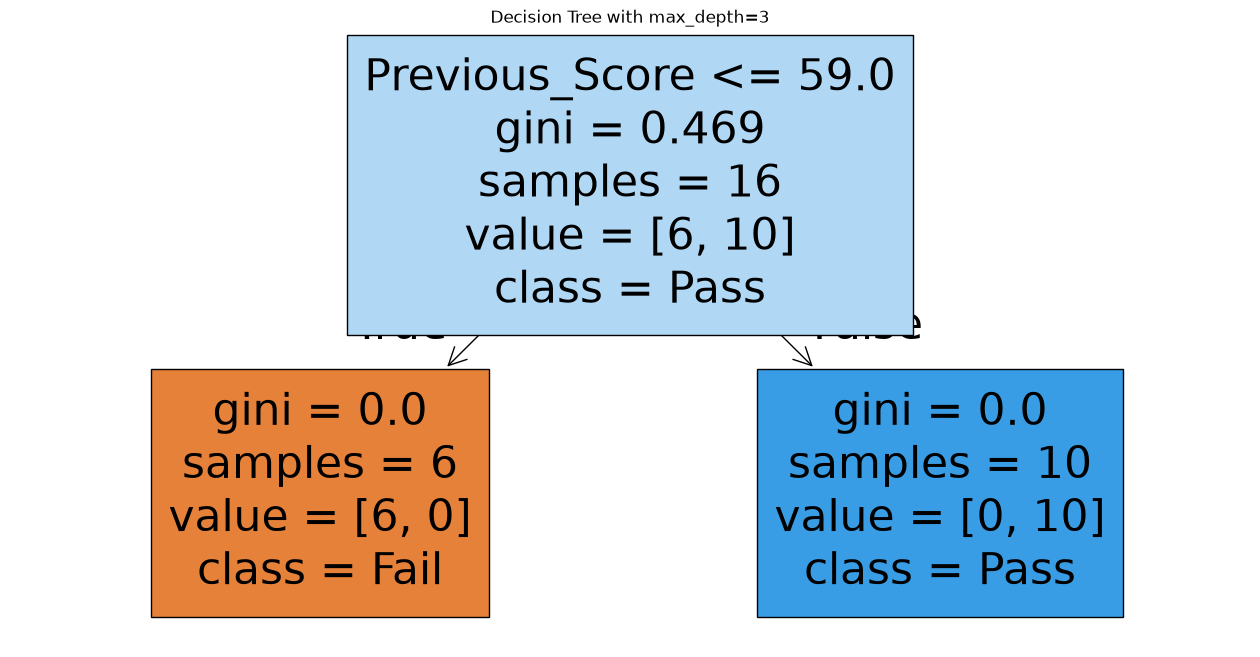

In [37]:
# Create a large figure for the simpler tree
plt.figure(figsize=(16, 8))

# Draw the simpler Decision Tree
plot_tree(
    simple_model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)

# Add a title to the visualization
plt.title("Decision Tree with max_depth=3")

# Display the tree
plt.show()


## 📌 Decision Tree — Complete Workflow

```text
Dataset
   ↓
EDA
   ↓
Features (X) + Target (y)
   ↓
Train/Test Split
   ↓
DecisionTreeClassifier
   ↓
Choose Split Criterion
   ↓
Gini / Entropy
   ↓
Best Feature + Threshold
   ↓
Train Model
   ↓
Predictions
   ↓
Evaluation
   ├── Accuracy
   ├── Confusion Matrix
   ├── Precision
   ├── Recall
   └── F1-score
   ↓
Tree Visualization
   ↓
Overfitting Control
   ↓
Prediction for New Data
```


## 📝 Key Takeaways

- Decision Tree is a **supervised Machine Learning algorithm**.
- It can be used for **classification and regression**.
- Classification trees predict categories/classes.
- A tree contains a **root, internal nodes, branches, and leaves**.
- Splitting divides data using feature-based conditions.
- Gini measures impurity.
- Entropy measures uncertainty.
- Information Gain measures entropy reduction.
- Decision Trees generally do **not require feature scaling**.
- Deep trees can overfit.
- `max_depth` can restrict tree complexity.
- `DecisionTreeClassifier` is used for classification.


## 🎤 Interview Questions

### 1. What is a Decision Tree?
A Decision Tree is a supervised Machine Learning algorithm that makes predictions using a sequence of feature-based decision rules.

### 2. What is a root node?
The root node is the first/top node where the tree begins splitting the data.

### 3. What is a leaf node?
A leaf node is the final node that contains the model's prediction.

### 4. What is Gini Impurity?
Gini Impurity measures how mixed the classes are in a node.

### 5. What is Entropy?
Entropy measures uncertainty or impurity in a node.

### 6. What is Information Gain?
Information Gain measures how much entropy is reduced after a split.

### 7. Does a Decision Tree require feature scaling?
Usually no. Decision Trees use threshold-based splits rather than distance calculations.

### 8. Why can Decision Trees overfit?
A very deep tree can learn noise and highly specific patterns from the training data.

### 9. How can we control overfitting?
We can use parameters such as `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes`.

### 10. Can Decision Trees handle nonlinear relationships?
Yes. Decision Trees can model many nonlinear relationships through recursive splits.

### 11. Can Decision Trees handle multiclass classification?
Yes. Decision Tree Classifiers can handle multiple classes.

### 12. What is the default criterion for `DecisionTreeClassifier`?
The default criterion is `gini`.

### 13. What is the difference between classification and regression trees?
Classification trees predict discrete classes, while regression trees predict continuous numerical values.
